**The Problem**  
LLMs are powerful but fundamentally limited. Here are 5 major limitations:

1. Stateless i.e. forgets converstaion context
2. Hallucinate i.e. make up facts confidently
3. No real-time data.
4. No actions i.e. can't book flights, or send emails.
5. Poor at precise mathematical calculations.

In [1]:
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY'] = userdata.get('gemini_key')

In [2]:
pip install langchain_community

In [3]:
pip install -U langchain-google-genai

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [6]:
response = llm.invoke("What is the current datatime")
response.content

'I cannot tell you the *exact* current datetime in real-time, as I don\'t have access to real-time information or a clock.\n\nHowever, you can easily find it by:\n\n*   **Checking your device\'s clock** (computer, phone, tablet).\n*   **Looking at the bottom right corner of your computer screen** (Windows) or top right (macOS).\n*   **Asking a search engine** like Google "what is the current time?"'

In [7]:

response = llm.invoke("What's the weather in NYC right now?")
response.content

"Right now in New York City, it's **72°F (22°C)** and **partly cloudy**. It feels like **74°F (23°C)**.\n\nThere's a light breeze from the southwest at about 5 mph."

**The Solution: AI Agents**  
An AI agent combines LLM reasoning with external tool execution to autonomously solve complex, multi-step problems that require both thinking and acting in the real world  

Think of it like this:

Agent = Reasoning and Decision Making (using LLMs) + Action (using Tools)

The LLM thinks (reasoning loop), decides (which tool/action), and acts (calls APIs/tools), then repeats until the goal is achieved.

In [8]:
from pydantic import BaseModel, Field

class MathInput(BaseModel):
    a: int = Field(description="The first number")
    b: int = Field(description="The second number")

In [9]:
# Building an Additional StructuredTool
from langchain.tools import tool

@tool(name_or_callable="addition", description="Add two numbers", args_schema=MathInput)
def add_tool(a: int, b: int) -> int:
    return a + b

In [10]:
result = add_tool.invoke({'a':33,'b':11})
print(result)
print(add_tool.name)
print(add_tool.description)
print(add_tool.args)

44
addition
Add two numbers
{'a': {'description': 'The first number', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number', 'title': 'B', 'type': 'integer'}}


**Introduction to Agents**  
What is an agent?  

Agents combine language models with tools to create systems that can reason about tasks, decide which tools to use, and iteratively work towards solutions.

An LLM Agent runs tools in a loop to achieve a goal. An agent runs until a stop condition is met - i.e., when the model emits a final output or an iteration limit is reached.

**What is react agent**  
ReAct is an agent pattern where the LLM alternates between Reason (think) and Act (use tools) in a loop until it solves the task. In short,

Agent = Reasoning and Decision Making (using LLMs) + Action (using Tools)

In [11]:
llm_u = llm.bind_tools([add_tool])

In [12]:
response = llm_u.invoke("What is the addtion of 111222 and 222211?")

print(f"Content: {response.content}")
print(f"Tool Call: {response.tool_calls}")

Content: 
Tool Call: [{'name': 'addition', 'args': {'a': 111222, 'b': 222211}, 'id': '84a4d0c1-e456-4f6d-9728-b0239a528c85', 'type': 'tool_call'}]


In [13]:
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  addition (84a4d0c1-e456-4f6d-9728-b0239a528c85)
 Call ID: 84a4d0c1-e456-4f6d-9728-b0239a528c85
  Args:
    a: 111222
    b: 222211


In [15]:
# define a dictionary with "name_or_callable" and function name
dict_with_tool_names = {
    "addition": add_tool
}

def custom_agent_executor(response):
    if response.tool_calls:
        for tool_calls in response.tool_calls:
            tool_name = tool_calls["name"]
            tool_args = tool_calls["args"]
            tool_func = dict_with_tool_names[tool_name]
            return tool_func.invoke(tool_args)
    else:
        return response.content

In [16]:

custom_agent_executor(llm_u.invoke("What is addition of 111222 and 222111?"))

333333

In [18]:
pip install ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 964.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 17.1 MB/s eta 0:00:00


In [17]:
from langchain_community.tools import DuckDuckGoSearchRun

In [21]:
dds = DuckDuckGoSearchRun()
dds

DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text'))

In [24]:
dds.invoke('messi india tour stadium chaos')

"The first stop of Lionel Messi's India tour took an unexpected turn as angry fans ripped up seats and hurled objects onto the pitch as chaos descended at Kolkata's Salt Lake Stadium. Lionel Messi's GOAT India Tour at Kolkata's Salt Lake Stadium saw chaos and fan unrest after poor event management and a brief appearance. A Kolkata court remanded the Messi India Tour organiser to 14-day police custody over chaos at Salt Lake stadium.A court in Bidhannagar on Saturday denied bail to Satadru Dutta, the promoter and organiser of star footballer Lionel Messi’s proposed G.O.A.T India Tour 2025. Lionel Messi returned to Kolkata after 14 years and was supposed to be a proud moment, but poor planning and mismanagement turns the whole event in total chaos. GOAT India Tour 2025 was scheduled to start from Vivekananda Yuba Bharati Krirangan (VYBK) Stadium in Salt... West Bengal Chief Minister Mamata Banerjee apologised to Lionel Messi and fans after chaos broke out at Salt Lake Stadium during the 

Create_agent

In [27]:
from datetime import datetime

def current_datetime() -> str:
    """This function tells the current date and time."""
    current_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    return f"{current_datetime}"

current_datetime()

'2026-04-21 08:10:09'

In [28]:
from langchain.agents import create_agent
agent = create_agent(
    model = llm,
    tools = [current_datetime,dds],
    system_prompt = "You are a helpful assistant,answer user queries concisely"

)

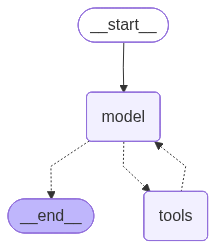

In [29]:

from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [30]:
response = agent.invoke({"messages": "What is the time?"})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is the time?
================================== Ai Message ==================================
Tool Calls:
  current_datetime (d9be9d61-c28f-465a-a319-67bef2754d64)
 Call ID: d9be9d61-c28f-465a-a319-67bef2754d64
  Args:
================================= Tool Message =================================
Name: current_datetime

2026-04-21 08:11:01
================================== Ai Message ==================================

The current time is 08:11:01 on April 21, 2026.
